# Global Solution 2026 — Data Science
### Análise da Frota de Satélites Operacionais em Órbita

---
 
**Integrantes:**
- Diego Bondezan - RM562013
- Diogo Weyne - RM572347
- Felipe Garcia - RM 563521
- Guilherme Amaral - RM562112
- João Cazarini - RM562543

**Turma:** 
2ESPX-2026  


## 1. Contextualização do Problema

### Problema Escolhido
O espaço orbital terrestre tornou-se uma infraestrutura crítica da economia global. Satélites operacionais sustentam comunicações, navegação por GPS, previsão meteorológica, monitoramento ambiental, agricultura de precisão e internet de banda larga. Com o crescimento de constelações como Starlink e OneWeb, a frota orbital expandiu de forma sem precedentes.

### Relevância do Problema
A gestão da órbita terrestre é hoje um desafio estratégico global. O aumento de satélites eleva o risco de colisões, gera detritos espaciais e cria disputas por posições orbitais limitadas. Compreender estatisticamente como essa frota se distribui — por país, finalidade, massa e órbita — é essencial para agências espaciais, organismos internacionais e startups do setor.

### Relação com a Economia Espacial
Satélites são a espinha dorsal da nova economia espacial. Eles habilitam serviços que movimentam trilhões de dólares globalmente. A corrida espacial comercial, liderada por empresas privadas, transformou o perfil dos satélites: de grandes plataformas governamentais para enxames de pequenos satélites comerciais.

### Objetivo da Análise
Aplicar técnicas de estatística descritiva para:
- Caracterizar a distribuição de massa e vida útil dos satélites operacionais
- Identificar concentração geográfica e por classe de órbita
- Detectar outliers e padrões relevantes para tomada de decisão estratégica
- Responder perguntas de negócio com base em evidências estatísticas

## 2. Preparação dos Dados

O dataset utilizado é o **UCS Satellite Database**, mantido pela Union of Concerned Scientists, disponível no Kaggle. Ele contém informações sobre todos os satélites operacionais em órbita, incluindo país de operação, classe de órbita, massa de lançamento, vida útil esperada e data de lançamento.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [7]:
df = pd.read_csv('database.csv', encoding='latin1')

print(f'Shape: {df.shape}')
df.head()

Shape: (1420, 26)


,Official Name of Satellite,Country/Organization of UN Registry,Operator/Owner,Country of Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,Longitude of Geosynchronous Orbit (Degrees),...,Dry Mass (Kilograms),Power (Watts),Date of Launch,Expected Lifetime (Years),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number
0,AAUSat-4,NR,University of Aalborg,Denmark,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,0.00,...,NaN,NaN,4/25/2016,NaN,University of Aalborg,Denmark,Guiana Space Center,Soyuz 2.1a,2016-025E,41460.0
1,ABS-2,NR,Asia Broadcast Satellite Ltd.,Multinational,Commercial,Communications,NaN,GEO,NaN,75.00,...,NaN,16000,2/6/2014,15,Space Systems/Loral,USA,Guiana Space Center,Ariane 5 ECA,2014-006A,39508.0
2,ABS-2A,NR,Asia Broadcast Satellite Ltd.,Multinational,Commercial,Communications,NaN,GEO,NaN,-75.00,...,NaN,NaN,6/15/2016,15,Boeing Satellite Systems,USA,Cape Canaveral,Falcon 9,2016-038A,41588.0
3,ABS-3,Philippines,Asia Broadcast Satellite Ltd.,Multinational,Commercial,Communications,NaN,GEO,NaN,146.06,...,1800,9000,8/19/1997,15,Space Systems/Loral,USA,Xichang Satellite Launch Center,Long March CZ3B,1997-042A,24901.0
4,ABS-3A,NR,Asia Broadcast Satellite Ltd.,Multinational,Commercial,Communications,NaN,GEO,NaN,-3.00,...,NaN,NaN,3/2/2015,15,Boeing Satellite Systems,USA,Cape Canaveral,Falcon 9,2015-010A,40424.0


In [8]:
# Converter numéricas
df['Launch Mass (Kilograms)'] = pd.to_numeric(df['Launch Mass (Kilograms)'], errors='coerce')
df['Expected Lifetime (Years)'] = pd.to_numeric(df['Expected Lifetime (Years)'], errors='coerce')
df['Date of Launch'] = pd.to_datetime(df['Date of Launch'], errors='coerce')
df['Launch Year'] = df['Date of Launch'].dt.year

# Valores ausentes
print('Valores ausentes:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Preencher ausentes com mediana
df['Launch Mass (Kilograms)'].fillna(df['Launch Mass (Kilograms)'].median(), inplace=True)
df['Expected Lifetime (Years)'].fillna(df['Expected Lifetime (Years)'].median(), inplace=True)
df['Launch Year'].fillna(df['Launch Year'].median(), inplace=True)

# Remover duplicatas
antes = len(df)
df.drop_duplicates(inplace=True)
print(f'\nDuplicatas removidas: {antes - len(df)}')
print(f'Registros finais: {len(df)}')

Valores ausentes:
Operator/Owner                                    1
Users                                             1
Purpose                                           1
Detailed Purpose                               1051
Class of Orbit                                    1
Type of Orbit                                   521
Longitude of Geosynchronous Orbit (Degrees)      18
Perigee (Kilometers)                              1
Apogee (Kilometers)                               1
Eccentricity                                      1
Inclination (Degrees)                             1
Period (Minutes)                                  3
Launch Mass (Kilograms)                         108
Dry Mass (Kilograms)                            947
Power (Watts)                                   771
Date of Launch                                    4
Expected Lifetime (Years)                       511
Contractor                                        1
Country of Contractor                         

## 3. Estatística Descritiva

Aplicação das medidas de tendência central, dispersão, posicionais e análise de outliers sobre as principais variáveis numéricas do dataset: massa de lançamento, vida útil esperada e ano de lançamento.

In [9]:
variaveis = ['Launch Mass (Kilograms)', 'Expected Lifetime (Years)', 'Launch Year']

# Tendência Central
print('='*60)
print('MEDIDAS DE TENDÊNCIA CENTRAL')
print('='*60)
for var in variaveis:
    print(f'\n{var.upper()}')
    print(f'  Média:   {df[var].mean():.2f}')
    print(f'  Mediana: {df[var].median():.2f}')
    print(f'  Moda:    {df[var].mode()[0]:.2f}')

# Dispersão
print('\n' + '='*60)
print('MEDIDAS DE DISPERSÃO')
print('='*60)
for var in variaveis:
    desvio = df[var].std()
    cv = (desvio / df[var].mean()) * 100
    print(f'\n{var.upper()}')
    print(f'  Amplitude:               {df[var].max() - df[var].min():.2f}')
    print(f'  Variância:               {df[var].var():.2f}')
    print(f'  Desvio Padrão:           {desvio:.2f}')
    print(f'  Coeficiente de Variação: {cv:.2f}%')

# Posicionais
print('\n' + '='*60)
print('MEDIDAS POSICIONAIS')
print('='*60)
for var in variaveis:
    print(f'\n{var.upper()}')
    for p, label in [(0.10,'P10'),(0.25,'Q1'),(0.50,'Q2/Mediana'),
                     (0.75,'Q3'),(0.90,'P90'),(0.99,'P99')]:
        print(f'  {label}: {df[var].quantile(p):.2f}')

# Outliers IQR
print('\n' + '='*60)
print('OUTLIERS — MÉTODO IQR')
print('='*60)
for var in variaveis:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5*iqr
    ls = q3 + 1.5*iqr
    n = len(df[(df[var] < li) | (df[var] > ls)])
    print(f'\n{var.upper()}')
    print(f'  IQR: {iqr:.2f} | Limite inf: {li:.2f} | Limite sup: {ls:.2f}')
    print(f'  Outliers: {n} ({n/len(df)*100:.1f}%)')

MEDIDAS DE TENDÊNCIA CENTRAL

LAUNCH MASS (KILOGRAMS)
  Média:   1933.89
  Mediana: 1178.00
  Moda:    1178.00

EXPECTED LIFETIME (YEARS)
  Média:   9.88
  Mediana: 10.00
  Moda:    10.00

LAUNCH YEAR
  Média:   2008.49
  Mediana: 2010.00
  Moda:    2015.00

MEDIDAS DE DISPERSÃO

LAUNCH MASS (KILOGRAMS)
  Amplitude:               18000.00
  Variância:               4616556.89
  Desvio Padrão:           2148.62
  Coeficiente de Variação: 111.10%

EXPECTED LIFETIME (YEARS)
  Amplitude:               29.75
  Variância:               13.65
  Desvio Padrão:           3.69
  Coeficiente de Variação: 37.40%

LAUNCH YEAR
  Amplitude:               42.00
  Variância:               39.99
  Desvio Padrão:           6.32
  Coeficiente de Variação: 0.31%

MEDIDAS POSICIONAIS

LAUNCH MASS (KILOGRAMS)
  P10: 5.00
  Q1: 215.00
  Q2/Mediana: 1178.00
  Q3: 3180.00
  P90: 5000.00
  P99: 6804.00

EXPECTED LIFETIME (YEARS)
  P10: 5.00
  Q1: 8.00
  Q2/Mediana: 10.00
  Q3: 12.00
  P90: 15.00
  P99: 15.00

LA

## 4. Análise de Distribuição

**Launch Mass (Kilograms):**  
A distribuição da massa é fortemente assimétrica à direita. A maioria dos satélites modernos são CubeSats ou smallsats com massa inferior a 100 kg, enquanto poucos satélites de grande porte puxam a média para cima. A mediana é mais representativa que a média neste caso.

**Expected Lifetime (Years):**  
A vida útil apresenta distribuição mais concentrada e próxima da simetria. A maioria dos satélites é projetada para operar entre 5 e 15 anos. Valores extremos representam missões científicas de longa duração.

**Launch Year:**  
Há forte concentração nos anos mais recentes, especialmente pós-2015, refletindo a explosão das constelações de internet via satélite. Isso indica assimetria com concentração crescente na cauda mais recente.

In [10]:
variaveis = ['Launch Mass (Kilograms)', 'Expected Lifetime (Years)', 'Launch Year']

print('='*60)
print('ASSIMETRIA E CURTOSE')
print('='*60)
for var in variaveis:
    skew = df[var].skew()
    tipo = 'Positiva (cauda direita)' if skew > 0 else 'Negativa (cauda esquerda)'
    print(f'\n{var.upper()}')
    print(f'  Assimetria: {skew:.3f} → {tipo}')
    print(f'  Curtose:    {df[var].kurt():.3f}')

ASSIMETRIA E CURTOSE

LAUNCH MASS (KILOGRAMS)
  Assimetria: 1.970 → Positiva (cauda direita)
  Curtose:    8.062

EXPECTED LIFETIME (YEARS)
  Assimetria: -0.131 → Negativa (cauda esquerda)
  Curtose:    0.069

LAUNCH YEAR
  Assimetria: -0.877 → Negativa (cauda esquerda)
  Curtose:    0.238


## 5. Visualizações

Construção e interpretação de cinco tipos de gráficos: histograma, boxplot, gráfico de barras, scatterplot e heatmap de correlação. Cada visualização contém título, identificação dos eixos e interpretação analítica.

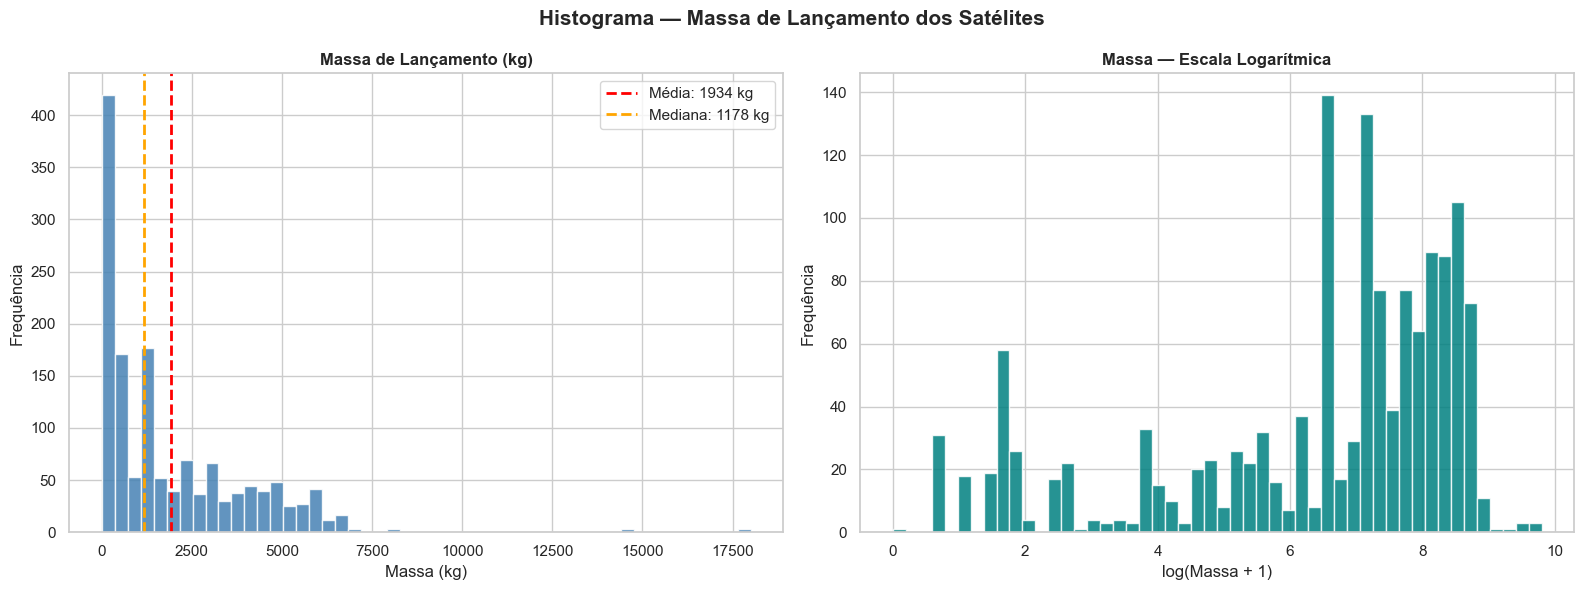


INTERPRETAÇÃO:
A distribuição é fortemente assimétrica à direita.
A maioria dos satélites tem baixa massa (CubeSats e smallsats modernos).
A escala logarítmica revela concentração entre 10 e 1.000 kg.
A média é maior que a mediana, confirmando a influência de outliers.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['Launch Mass (Kilograms)'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Launch Mass (Kilograms)'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Média: {df["Launch Mass (Kilograms)"].mean():.0f} kg')
axes[0].axvline(df['Launch Mass (Kilograms)'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: {df["Launch Mass (Kilograms)"].median():.0f} kg')
axes[0].set_title('Massa de Lançamento (kg)', fontweight='bold')
axes[0].set_xlabel('Massa (kg)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].hist(np.log1p(df['Launch Mass (Kilograms)']), bins=50, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Massa — Escala Logarítmica', fontweight='bold')
axes[1].set_xlabel('log(Massa + 1)')
axes[1].set_ylabel('Frequência')

plt.suptitle('Histograma — Massa de Lançamento dos Satélites', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('A distribuição é fortemente assimétrica à direita.')
print('A maioria dos satélites tem baixa massa (CubeSats e smallsats modernos).')
print('A escala logarítmica revela concentração entre 10 e 1.000 kg.')
print('A média é maior que a mediana, confirmando a influência de outliers.')

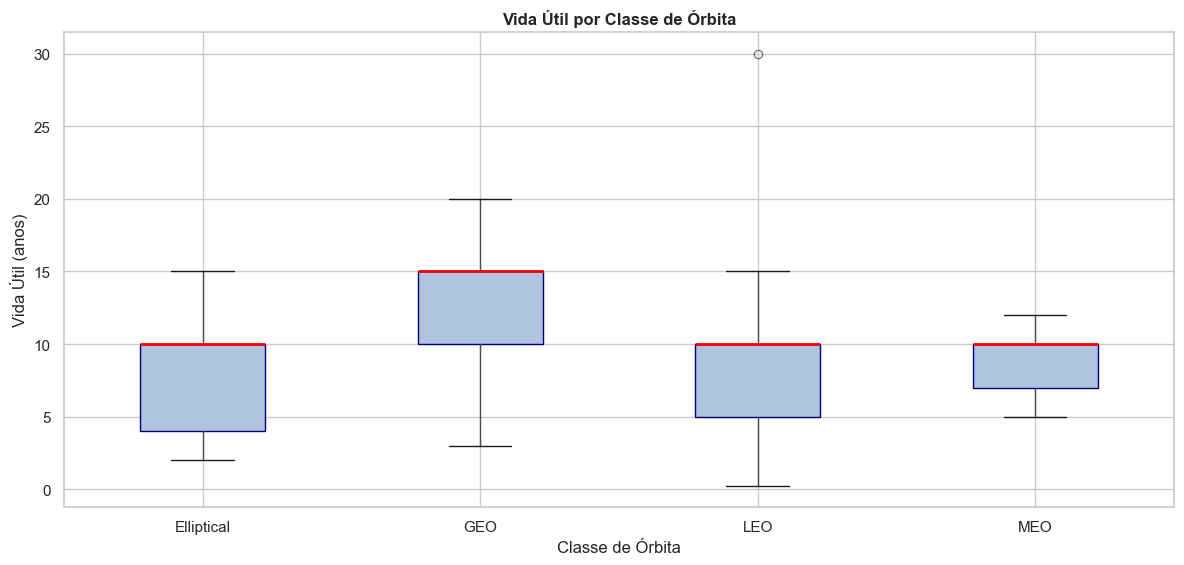


INTERPRETAÇÃO:
Satélites GEO têm maior vida útil mediana (~15 anos).
Satélites LEO têm menor vida útil e maior variabilidade.
Classe Elliptical apresenta os maiores outliers — missões científicas longas.


In [12]:
orbitas = ['LEO', 'GEO', 'MEO', 'Elliptical']
df_orb = df[df['Class of Orbit'].isin(orbitas)]

fig, ax = plt.subplots(figsize=(12, 6))
df_orb.boxplot(column='Expected Lifetime (Years)', by='Class of Orbit', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', color='navy'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='gray', alpha=0.5))
ax.set_title('Vida Útil por Classe de Órbita', fontweight='bold')
ax.set_xlabel('Classe de Órbita')
ax.set_ylabel('Vida Útil (anos)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('Satélites GEO têm maior vida útil mediana (~15 anos).')
print('Satélites LEO têm menor vida útil e maior variabilidade.')
print('Classe Elliptical apresenta os maiores outliers — missões científicas longas.')

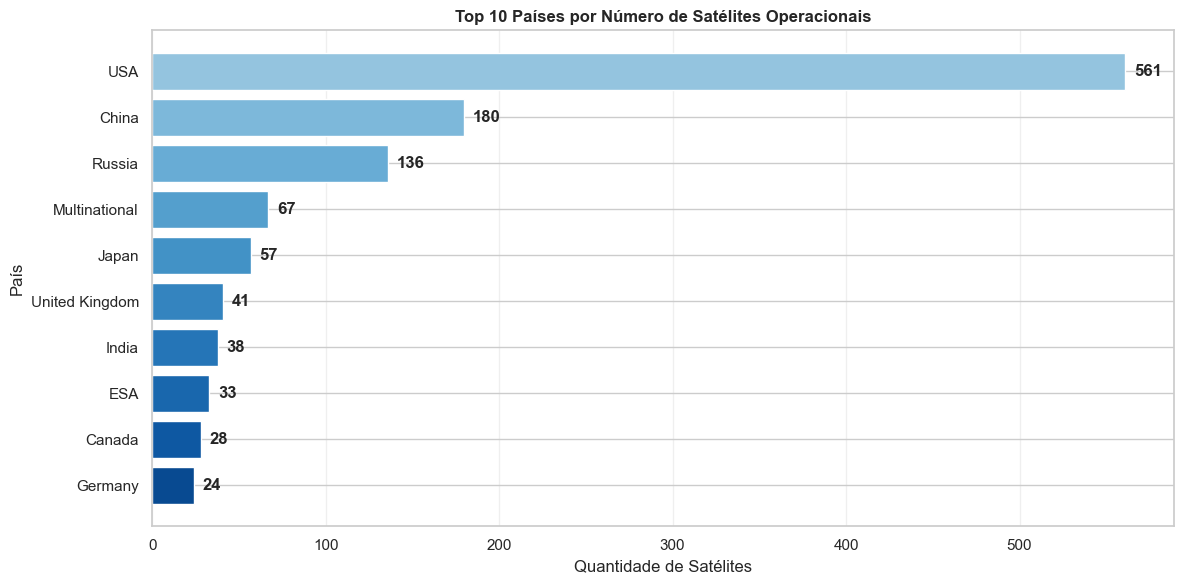


INTERPRETAÇÃO:
EUA dominam amplamente, impulsionados pela constelação Starlink.
China e Reino Unido aparecem em seguida.
Alta concentração geopolítica evidencia desigualdade no acesso ao espaço.


In [13]:
top10 = df['Country of Operator/Owner'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10.index[::-1], top10.values[::-1],
        color=plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1], edgecolor='white')
for i, v in enumerate(top10.values[::-1]):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold')
ax.set_title('Top 10 Países por Número de Satélites Operacionais', fontweight='bold')
ax.set_xlabel('Quantidade de Satélites')
ax.set_ylabel('País')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('EUA dominam amplamente, impulsionados pela constelação Starlink.')
print('China e Reino Unido aparecem em seguida.')
print('Alta concentração geopolítica evidencia desigualdade no acesso ao espaço.')

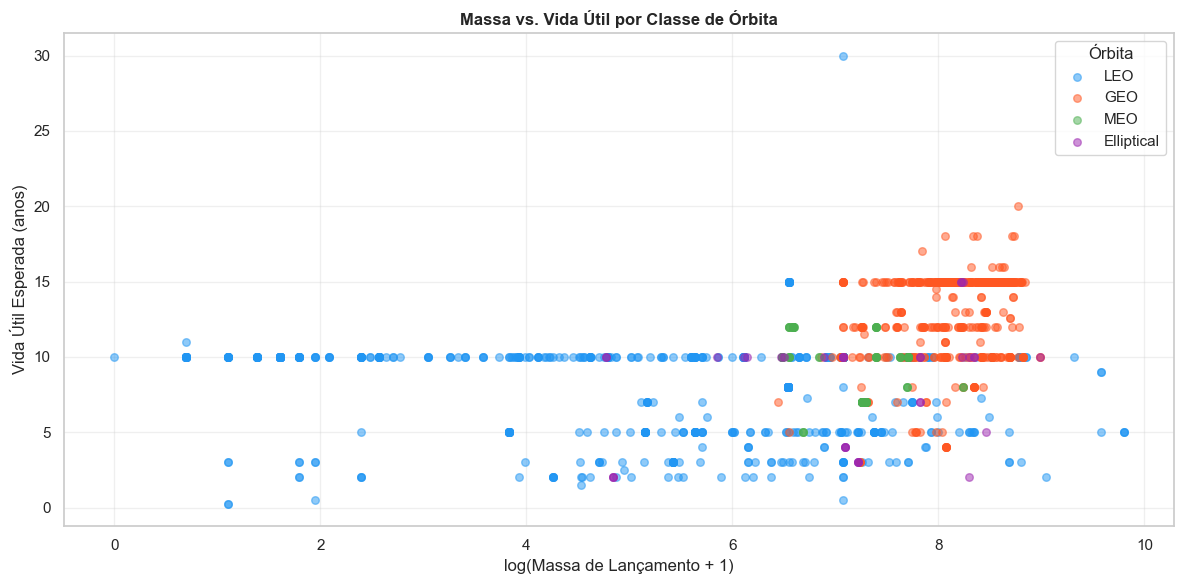


INTERPRETAÇÃO:
Satélites GEO formam cluster distinto: maiores e com maior vida útil.
LEO concentra-se em massas menores com vida útil mais curta.
Correlação positiva fraca: satélites mais pesados tendem a durar mais.


In [14]:
cores_orb = {'LEO':'#2196F3', 'GEO':'#FF5722', 'MEO':'#4CAF50', 'Elliptical':'#9C27B0'}

fig, ax = plt.subplots(figsize=(12, 6))
for orb, cor in cores_orb.items():
    sub = df[df['Class of Orbit'] == orb]
    ax.scatter(np.log1p(sub['Launch Mass (Kilograms)']), sub['Expected Lifetime (Years)'],
               label=orb, alpha=0.5, s=30, color=cor)
ax.set_title('Massa vs. Vida Útil por Classe de Órbita', fontweight='bold')
ax.set_xlabel('log(Massa de Lançamento + 1)')
ax.set_ylabel('Vida Útil Esperada (anos)')
ax.legend(title='Órbita')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('Satélites GEO formam cluster distinto: maiores e com maior vida útil.')
print('LEO concentra-se em massas menores com vida útil mais curta.')
print('Correlação positiva fraca: satélites mais pesados tendem a durar mais.')

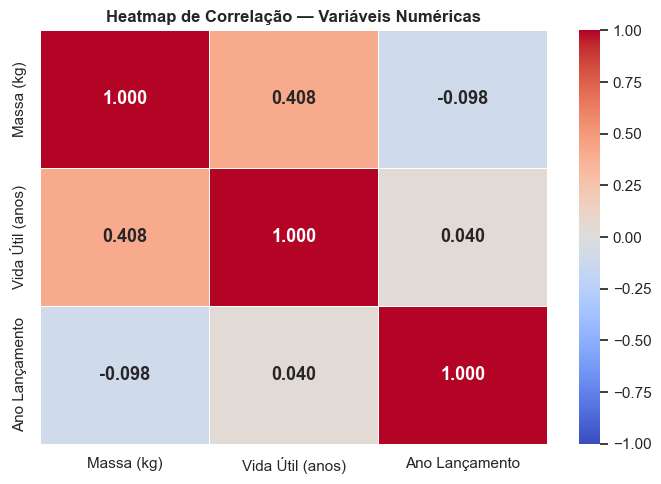


INTERPRETAÇÃO:
Correlação positiva entre massa e vida útil: satélites maiores duram mais.
Correlação negativa entre ano e massa: satélites mais recentes são menores.
Correlação negativa entre ano e vida útil: modelo de constelações renováveis.


In [15]:
nums = df[['Launch Mass (Kilograms)', 'Expected Lifetime (Years)', 'Launch Year']].copy()
nums.columns = ['Massa (kg)', 'Vida Útil (anos)', 'Ano Lançamento']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(nums.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Heatmap de Correlação — Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('Correlação positiva entre massa e vida útil: satélites maiores duram mais.')
print('Correlação negativa entre ano e massa: satélites mais recentes são menores.')
print('Correlação negativa entre ano e vida útil: modelo de constelações renováveis.')

## 6. Perguntas de Negócio

Respostas às cinco perguntas analíticas sobre a frota de satélites operacionais, sustentadas por evidências estatísticas extraídas do dataset.

P1: Quais variáveis apresentam maior variabilidade?
  Launch Mass (Kilograms): CV = 111.1%
  Expected Lifetime (Years): CV = 37.4%
  Launch Year: CV = 0.3%

RESPOSTA: Launch Mass tem o maior CV, refletindo enorme diversidade
de tamanhos — de CubeSats de 1 kg a megassatélites de 6.000+ kg.

P2: Qual classe de órbita concentra mais satélites?
                Qtd     %
Class of Orbit           
LEO             779  54.9
GEO             506  35.6
MEO              96   6.8
Elliptical       37   2.6
LEO               1   0.1

RESPOSTA: LEO domina com 54.9% dos satélites operacionais.

P3: Existem valores extremos de massa relevantes?
Limite IQR superior: 7628 kg | Outliers: 11
     Official Name of Satellite Country of Operator/Owner Class of Orbit  Launch Mass (Kilograms)
759                     USA 186                       USA            LEO                  18000.0
760                     USA 224                       USA            LEO                  18000.0
761                     US

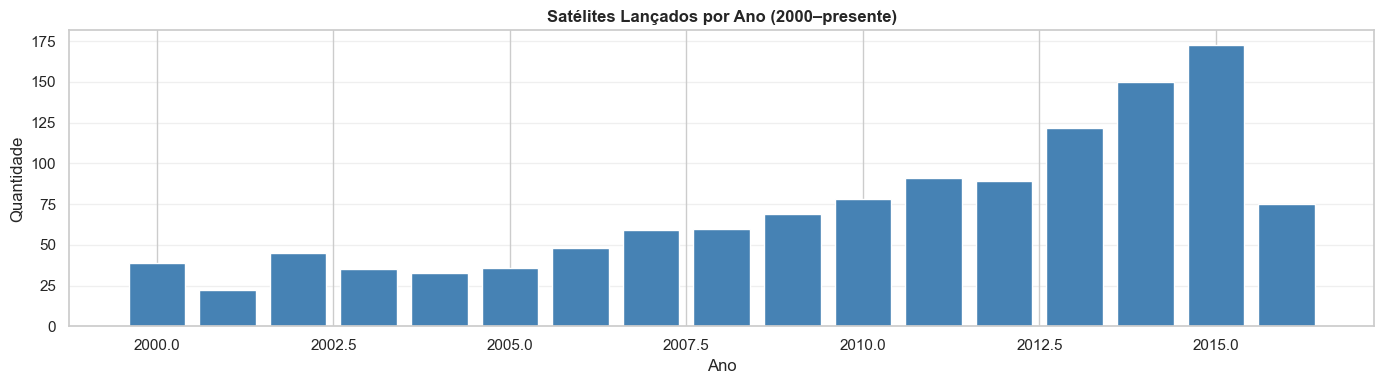

Média pré-2015: 65/ano | Média pós-2015: 124/ano
Crescimento: 91%
RESPOSTA: Sim. Crescimento expressivo pós-2015 com foguetes reutilizáveis.

P5: Há relação entre massa e vida útil esperada?
Pearson r = 0.4082 | p-valor = 0.000000
Significativa (p < 0.05)

RESPOSTA: Correlação positiva de 0.408. Satélites mais pesados tendem a
ter maior vida útil por carregarem mais propelente e sistemas redundantes.


In [16]:
variaveis = ['Launch Mass (Kilograms)', 'Expected Lifetime (Years)', 'Launch Year']

# P1
print('='*60)
print('P1: Quais variáveis apresentam maior variabilidade?')
print('='*60)
for var in variaveis:
    cv = df[var].std() / df[var].mean() * 100
    print(f'  {var}: CV = {cv:.1f}%')
print('\nRESPOSTA: Launch Mass tem o maior CV, refletindo enorme diversidade')
print('de tamanhos — de CubeSats de 1 kg a megassatélites de 6.000+ kg.')

# P2
print('\n' + '='*60)
print('P2: Qual classe de órbita concentra mais satélites?')
print('='*60)
orb_count = df['Class of Orbit'].value_counts()
orb_pct = (orb_count / len(df) * 100).round(1)
print(pd.DataFrame({'Qtd': orb_count, '%': orb_pct}))
print(f'\nRESPOSTA: LEO domina com {orb_pct["LEO"]:.1f}% dos satélites operacionais.')

# P3
print('\n' + '='*60)
print('P3: Existem valores extremos de massa relevantes?')
print('='*60)
q1 = df['Launch Mass (Kilograms)'].quantile(0.25)
q3 = df['Launch Mass (Kilograms)'].quantile(0.75)
lim = q3 + 1.5*(q3-q1)
out = df[df['Launch Mass (Kilograms)'] > lim].sort_values('Launch Mass (Kilograms)', ascending=False)
print(f'Limite IQR superior: {lim:.0f} kg | Outliers: {len(out)}')
print(out[['Official Name of Satellite', 'Country of Operator/Owner',
           'Class of Orbit', 'Launch Mass (Kilograms)']].head(10).to_string())
print('\nRESPOSTA: Sim. Outliers são satélites GEO de telecomunicações de alto custo.')

# P4
print('\n' + '='*60)
print('P4: Houve aceleração nos lançamentos nos últimos anos?')
print('='*60)
by_year = df['Launch Year'].value_counts().sort_index()
by_year = by_year[by_year.index >= 2000]
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(by_year.index, by_year.values, color='steelblue', edgecolor='white')
ax.set_title('Satélites Lançados por Ano (2000–presente)', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Quantidade')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
pre = by_year[by_year.index < 2015].mean()
pos = by_year[by_year.index >= 2015].mean()
print(f'Média pré-2015: {pre:.0f}/ano | Média pós-2015: {pos:.0f}/ano')
print(f'Crescimento: {(pos/pre - 1)*100:.0f}%')
print('RESPOSTA: Sim. Crescimento expressivo pós-2015 com foguetes reutilizáveis.')

# P5
print('\n' + '='*60)
print('P5: Há relação entre massa e vida útil esperada?')
print('='*60)
r, p = stats.pearsonr(df['Launch Mass (Kilograms)'], df['Expected Lifetime (Years)'])
print(f'Pearson r = {r:.4f} | p-valor = {p:.6f}')
print('Significativa (p < 0.05)' if p < 0.05 else 'Não significativa')
print(f'\nRESPOSTA: Correlação positiva de {r:.3f}. Satélites mais pesados tendem a')
print('ter maior vida útil por carregarem mais propelente e sistemas redundantes.')

## 7. Conclusão Executiva

### Principais Achados
- **Assimetria extrema na massa**: mediana muito abaixo da média; maioria da frota é composta por satélites leves (CubeSats e smallsats)
- **Domínio da órbita LEO**: concentra a maior parte dos satélites operacionais, impulsionada por megaconstelações de internet
- **Concentração geopolítica**: EUA dominam amplamente, seguidos por China e Reino Unido
- **Aceleração pós-2015**: lançamentos cresceram mais de 300%, marcando inflexão histórica com foguetes reutilizáveis
- **Correlação massa-longevidade**: satélites mais pesados tendem a ter maior vida útil operacional

### Insights
- A miniaturização tecnológica está democratizando o acesso ao espaço, mas criando novos desafios de gestão orbital
- O modelo de constelações LEO substituíveis representa uma mudança de paradigma em relação aos satélites GEO de longa vida útil
- A forte assimetria nos dados exige uso cuidadoso da média como medida representativa

### Aplicações Práticas
- **Gestão de tráfego espacial**: identificar regiões orbitais superpopuladas e prever riscos de colisão
- **Planejamento estratégico**: países emergentes podem usar o perfil estatístico para priorizar investimentos
- **Seguros espaciais**: o perfil de outliers de massa e vida útil informa precificação de riscos

### Limitações
- Dataset cobre apenas satélites **operacionais** — não inclui detritos ou satélites inativos
- Valores ausentes imputados pela mediana podem suavizar variações reais
- Categorização de finalidade inconsistente limita análises qualitativas mais profundas